In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from epymodelingsuite.multistrain.formatter import (
    compute_quantiles,
    add_state_abbreviations,
    create_ed_submission,
    create_ed_quantile_submission,
    STATE_ABBREV,
    LOCATION_CODES,
)
from epymodelingsuite.multistrain.aggregator import pull_single_strain_submission
from epymodelingsuite.schema.output import (
    get_flusight_quantiles,
    get_flusight_horizons
)

## Configuration

Set timespan configs:

In [13]:
SUBMISSION_WEEK = "202614"
REFERENCE_DATE = "2026-04-11"
WINDOW = "202550-202613"

These configs are unlikely to need changing:

In [3]:
DIST_FUNC = "wrmse"
STRAINS = "h1-h3-b"
TARGET = "ed"
TARGET_LONG = "flu_prop-ed_25"

Derived config values:

In [4]:
REFERENCE_DT = pd.to_datetime(REFERENCE_DATE)
final_date = REFERENCE_DT + pd.Timedelta(weeks=4)
final_date

Timestamp('2026-05-06 00:00:00')

## Data

In [5]:
# Load single-strain submission file
single_source_location = f"gs://gs_mobs_jessica/pipeline/flu/{SUBMISSION_WEEK}/{TARGET}_smc_{DIST_FUNC}_{WINDOW}/*/outputs/*"
single_fname = f"output_hub_formatted.csv.gz"
df_single = pull_single_strain_submission(source_location=single_source_location, fname=single_fname)
df_single.head()

Copying gs://gs_mobs_jessica/pipeline/flu/202614/ed_smc_wrmse_202550-202613/20260408-183001-8ee65c20/outputs/20260408-204654_ed-prop/output_hub_formatted.csv.gz to file:///tmp/tmpjkh4jtrj/output_hub_formatted.csv.gz
  


Downloaded: output_hub_formatted.csv.gz


.


,location,reference_date,horizon,target_end_date,target,output_type,output_type_id,value
0,US,2026-04-11,-1,2026-04-04,wk inc flu prop ed visits,quantile,0.01,0.000055
1,US,2026-04-11,0,2026-04-11,wk inc flu prop ed visits,quantile,0.01,0.000013
2,US,2026-04-11,1,2026-04-18,wk inc flu prop ed visits,quantile,0.01,0.000003
3,US,2026-04-11,2,2026-04-25,wk inc flu prop ed visits,quantile,0.01,0.000000
4,US,2026-04-11,3,2026-05-02,wk inc flu prop ed visits,quantile,0.01,0.000000


In [6]:
# Load ground truth hospital data
fit_surv_data = pd.read_csv(f"../flu-forecast-epydemix/common-data/surveillance/{TARGET_LONG}_{SUBMISSION_WEEK}_scaled_multi.csv")
fit_surv_data['abbreviation'] = fit_surv_data['location_iso'].apply(lambda key: key.split("-")[-1])
fit_surv_data['date'] = pd.to_datetime(fit_surv_data['date'])

# Compute quantiles for both sampling methods
random_combined = pd.read_csv(f"../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/trajectories_aggregated.csv")
random_quantiles = compute_quantiles(random_combined)

# Add abbreviations
random_quantiles = add_state_abbreviations(random_quantiles)
random_quantiles['date'] = pd.to_datetime(random_quantiles['date'])

# Get sorted list of populations (US first, then states alphabetically)
populations = sorted(random_quantiles['location'].unique())
populations = ['United_States'] + [p for p in populations if p != 'United_States']

print(f"Plotting {len(populations)} locations")

Plotting 51 locations


In [7]:
print(f"Quantiles shape: {random_quantiles.shape}")
print(f"Quantile columns: {[c for c in random_quantiles.columns if c.startswith('q')]}")
random_quantiles.head(10)

Quantiles shape: (1785, 26)
Quantile columns: ['q010', 'q025', 'q050', 'q100', 'q150', 'q200', 'q250', 'q300', 'q350', 'q400', 'q450', 'q500', 'q550', 'q600', 'q650', 'q700', 'q750', 'q800', 'q850', 'q900', 'q950', 'q975', 'q990']


,location,date,q010,q025,q050,q100,q150,q200,q250,q300,...,q650,q700,q750,q800,q850,q900,q950,q975,q990,abbreviation
0,United_States,2025-09-20,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000438,0.001445,0.003270,0.004781,US
1,United_States,2025-09-27,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000365,0.001082,0.001999,0.003183,0.006288,0.007313,0.009053,US
2,United_States,2025-10-04,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.001000,0.001620,0.002268,0.003157,0.004652,0.006280,0.008611,0.009416,0.011314,US
3,United_States,2025-10-11,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.002378,0.003033,0.003769,0.005029,0.005730,0.007965,0.010911,0.013114,0.013799,US
4,United_States,2025-10-18,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.003613,0.004241,0.004837,0.005736,0.006730,0.008600,0.012177,0.016253,0.017207,US
5,United_States,2025-10-25,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000463,0.001038,...,0.004579,0.005068,0.005702,0.006457,0.007629,0.009620,0.013609,0.018939,0.020570,US
6,United_States,2025-11-01,0.00000,0.00000,0.000000,0.000000,0.000440,0.000944,0.001532,0.002058,...,0.005448,0.005921,0.006694,0.007785,0.008991,0.010467,0.015568,0.020942,0.023583,US
7,United_States,2025-11-08,0.00000,0.00000,0.000000,0.001064,0.001641,0.002272,0.002795,0.003266,...,0.007092,0.007734,0.008473,0.009625,0.010932,0.012642,0.018331,0.024513,0.027329,US
8,United_States,2025-11-15,0.00000,0.00070,0.001522,0.002284,0.002950,0.003535,0.004143,0.004599,...,0.009036,0.009817,0.010616,0.011575,0.012788,0.014540,0.020728,0.026755,0.030923,US
9,United_States,2025-11-22,0.00068,0.00189,0.002730,0.003568,0.004558,0.005170,0.005847,0.006366,...,0.011225,0.012064,0.013130,0.014149,0.015585,0.017770,0.024163,0.030049,0.036502,US


## Plot

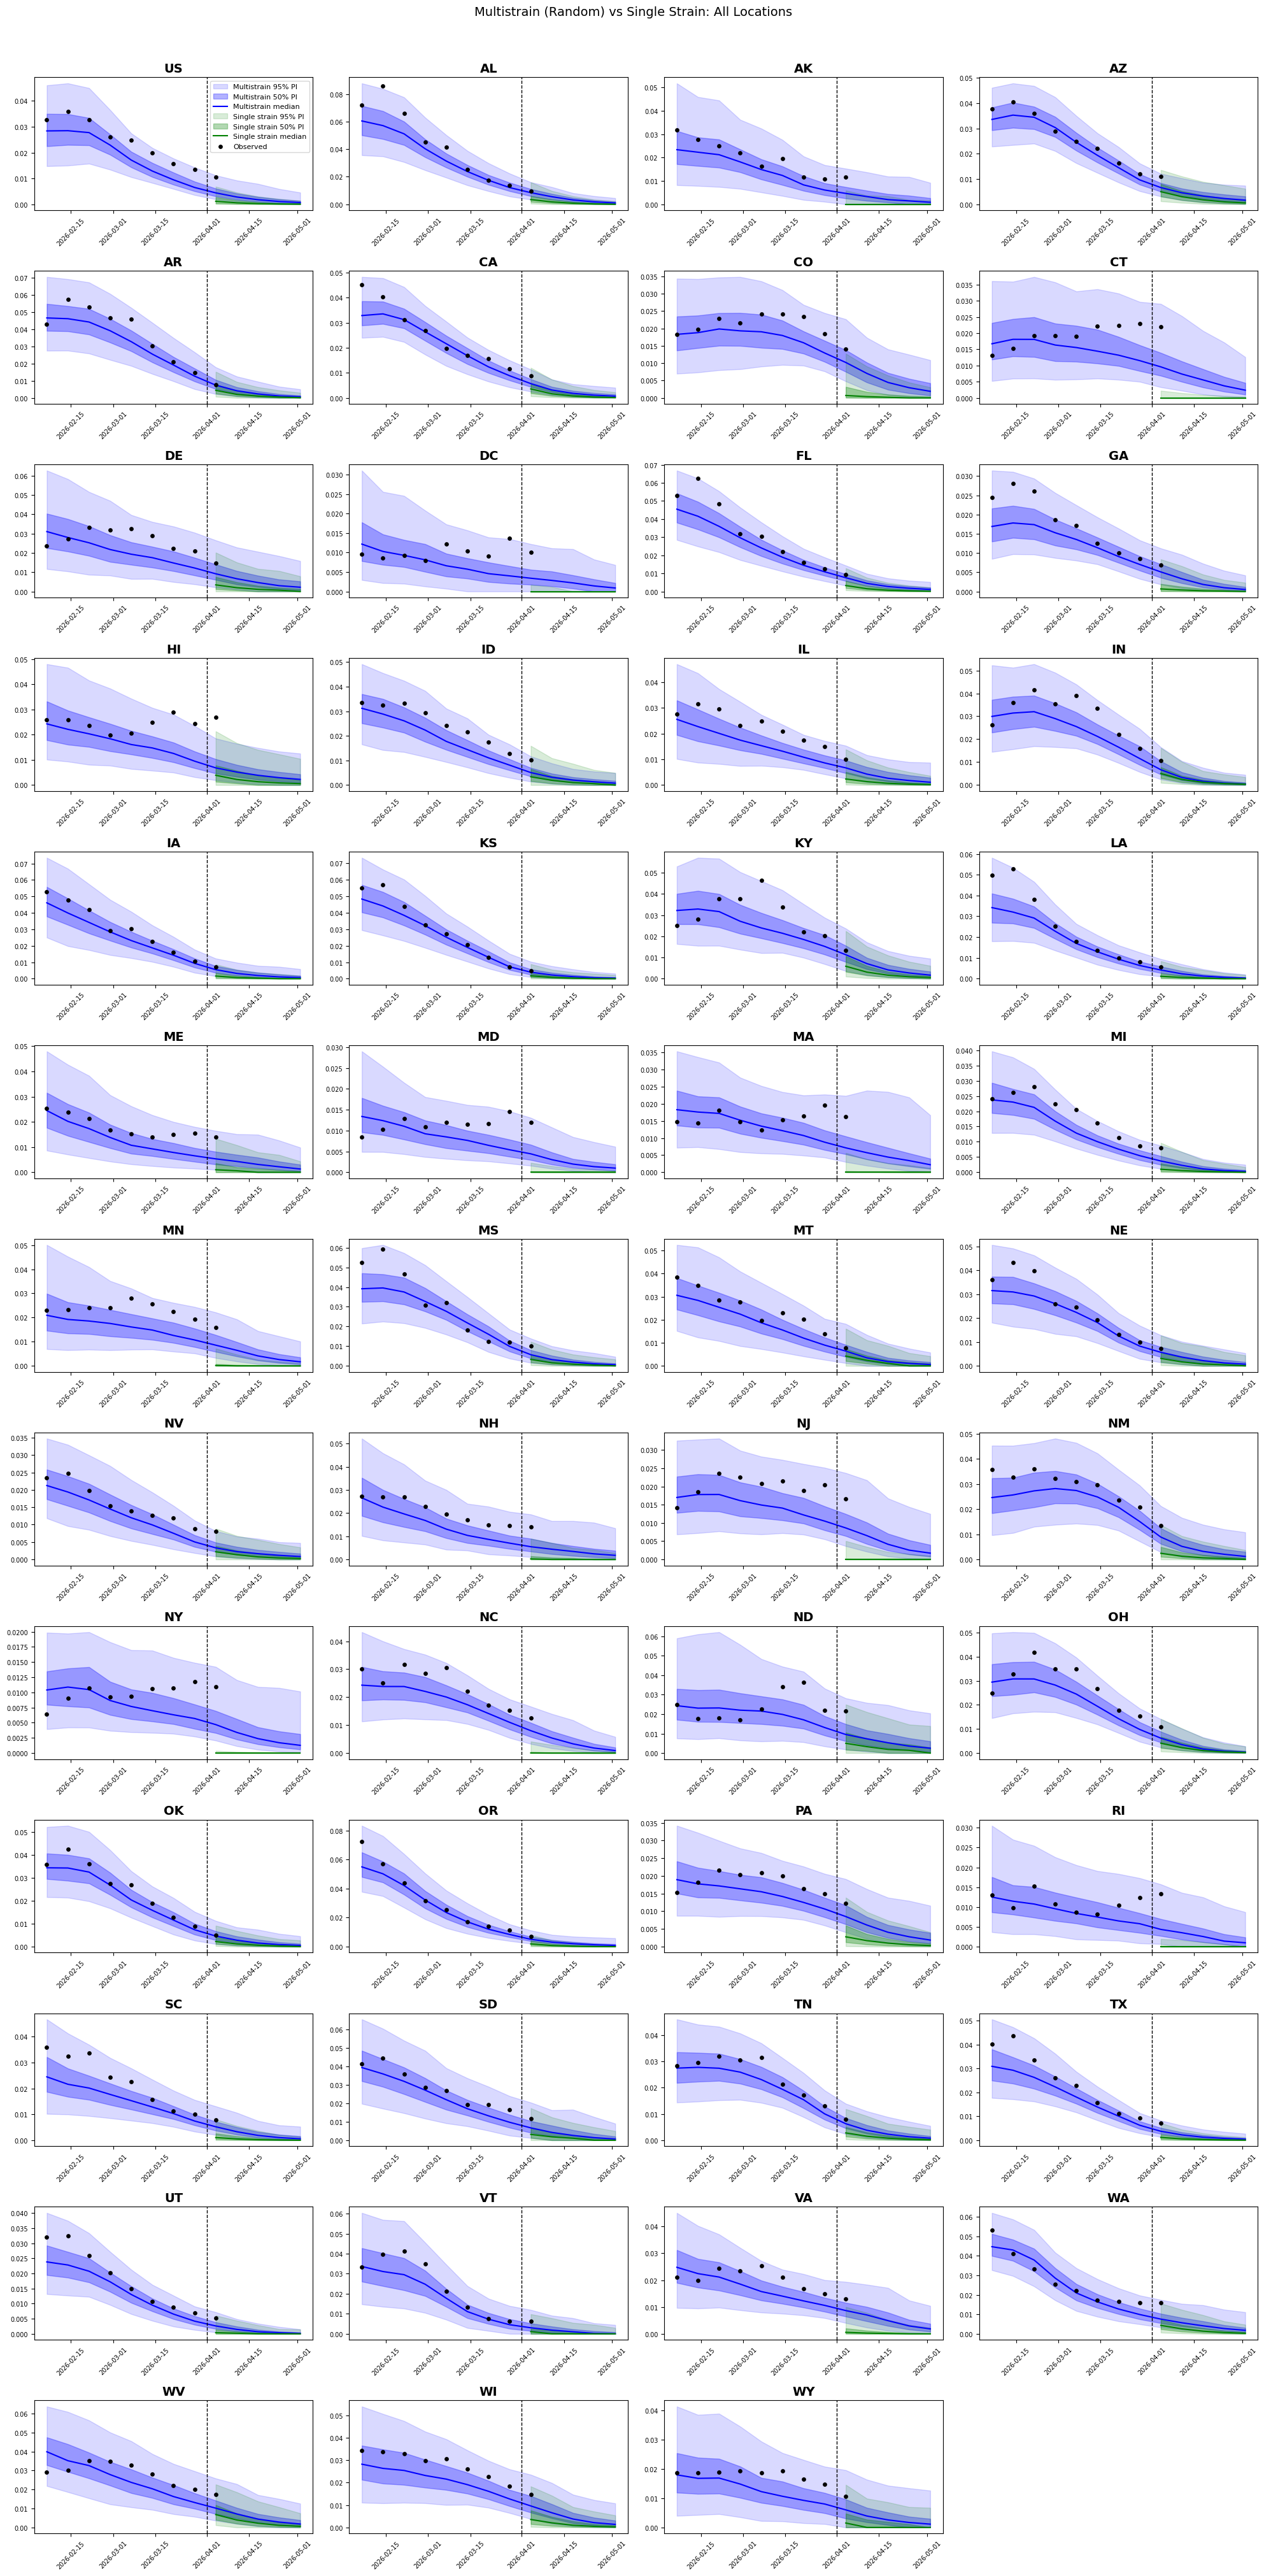

In [10]:
FILTER_PLOT = True

if FILTER_PLOT:
    plot_start_date = pd.to_datetime('2026-02-01')
    plot_prefix = 'filtered_'
else:
    plot_start_date = pd.to_datetime('2025-10-01')
    plot_prefix = ''

random_quantiles_filter = random_quantiles[(random_quantiles['date'] >= plot_start_date) & (random_quantiles['date'] < final_date)]

fit_surv_data_filter = fit_surv_data[(fit_surv_data['date'] >= plot_start_date) & (fit_surv_data['date'] < final_date)]



# Convert df_single to wide format for plotting (matching random_quantiles format)
df_single_quantiles = df_single[df_single['output_type'] == 'quantile'].copy()
df_single_quantiles['target_end_date'] = pd.to_datetime(df_single_quantiles['target_end_date'])

# Pivot to get quantile columns
df_single_wide = df_single_quantiles.pivot_table(
    index=['location', 'target_end_date'],
    columns='output_type_id',
    values='value'
).reset_index()

# Rename columns to match random_quantiles format
df_single_wide.columns.name = None
df_single_wide = df_single_wide.rename(columns={
    'target_end_date': 'date',
    '0.025': 'q025', '0.25': 'q250', '0.5': 'q500', '0.75': 'q750', '0.975': 'q975'
})

# Filter to date range
df_single_filter = df_single_wide[
    (df_single_wide['date'] >= plot_start_date) & 
    (df_single_wide['date'] < final_date)
]

# Create 13x4 comparison figure: Random multistrain vs Single strain
fig, axes = plt.subplots(13, 4, figsize=(20, 40))
axes = axes.flatten()

for idx, pop in enumerate(populations):
    ax = axes[idx]
    abbrev = STATE_ABBREV.get(pop, pop)
    location_code = LOCATION_CODES.get(abbrev, abbrev)
    
    # Get data for this population
    rand_pop = random_quantiles_filter[random_quantiles_filter['location'] == pop].sort_values('date')
    single_pop = df_single_filter[df_single_filter['location'] == location_code].sort_values('date')
    fit_surv_data_pop = fit_surv_data_filter[fit_surv_data_filter['abbreviation'] == abbrev].sort_values('date')
    
    # Plot random multistrain sampling (blue)
    ax.fill_between(rand_pop['date'], rand_pop['q025'], rand_pop['q975'], 
                    alpha=0.15, color='blue', label='Multistrain 95% PI')
    ax.fill_between(rand_pop['date'], rand_pop['q250'], rand_pop['q750'], 
                    alpha=0.3, color='blue', label='Multistrain 50% PI')
    ax.plot(rand_pop['date'], rand_pop['q500'], 'b-', linewidth=1.5, label='Multistrain median')
    
    # Plot single strain (green)
    ax.fill_between(single_pop['date'], single_pop['q025'], single_pop['q975'], 
                    alpha=0.15, color='green', label='Single strain 95% PI')
    ax.fill_between(single_pop['date'], single_pop['q250'], single_pop['q750'], 
                    alpha=0.3, color='green', label='Single strain 50% PI')
    ax.plot(single_pop['date'], single_pop['q500'], 'g-', linewidth=1.5, label='Single strain median')
    
    # Plot ground truth (black markers)
    ax.scatter(fit_surv_data_pop['date'], fit_surv_data_pop['original_value'], 
               color='black', s=15, zorder=5, label='Observed')
    
    ax.set_title(abbrev, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axvline(REFERENCE_DT - pd.Timedelta(weeks=1), color='black', linestyle='--', linewidth=1)
    
    # Only show legend for first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide any unused subplots
for idx in range(len(populations), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Multistrain (Random) vs Single Strain: All Locations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/{plot_prefix}multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}_multistrain_vs_single_comparison.pdf', 
            dpi=150, bbox_inches='tight')
plt.show()

## Submission File

In [14]:
# Create complete FluSight submission
submission = create_ed_submission(
    trajectories_df=random_combined,
    reference_date=REFERENCE_DATE,
    horizons=get_flusight_horizons(),  # -1 is nowcast, 0-3 are forecasts
    value_col='target_total'
)

print(f"Submission shape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nTargets: {submission['target'].unique()}")
print(f"Output types: {submission['output_type'].unique()}")
print(f"Horizons: {sorted(submission['horizon'].unique())}")
print(f"Locations: {submission['location'].nunique()}")
print(f"\nRows per target:")
print(submission.groupby(['target', 'output_type']).size())

Submission shape: (5865, 8)

Columns: ['reference_date', 'horizon', 'target_end_date', 'location', 'target', 'output_type', 'output_type_id', 'value']

Targets: <StringArray>
['wk inc flu prop ed visits']
Length: 1, dtype: str
Output types: <StringArray>
['quantile']
Length: 1, dtype: str
Horizons: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Locations: 51

Rows per target:
target                     output_type
wk inc flu prop ed visits  quantile       5865
dtype: int64


In [15]:
submission

,reference_date,horizon,target_end_date,location,target,output_type,output_type_id,value
0,2026-04-11,-1,2026-04-04,01,wk inc flu prop ed visits,quantile,0.01,0.003
1,2026-04-11,-1,2026-04-04,01,wk inc flu prop ed visits,quantile,0.025,0.003
2,2026-04-11,-1,2026-04-04,01,wk inc flu prop ed visits,quantile,0.05,0.004
3,2026-04-11,-1,2026-04-04,01,wk inc flu prop ed visits,quantile,0.1,0.005
4,2026-04-11,-1,2026-04-04,01,wk inc flu prop ed visits,quantile,0.15,0.005
...,...,...,...,...,...,...,...,...
5860,2026-04-11,3,2026-05-02,US,wk inc flu prop ed visits,quantile,0.85,0.002
5861,2026-04-11,3,2026-05-02,US,wk inc flu prop ed visits,quantile,0.9,0.002
5862,2026-04-11,3,2026-05-02,US,wk inc flu prop ed visits,quantile,0.95,0.004
5863,2026-04-11,3,2026-05-02,US,wk inc flu prop ed visits,quantile,0.975,0.005


In [16]:
submission.to_csv(f"../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/{REFERENCE_DATE}-MOBS-EpyStrain_Flu.csv",
                  index=False)